# Rapport de nettoyage et d'analyse des données

## 1. Analyse des valeurs manquantes (NaN)

### Cas 1 : **No Driver Found**

| Variable | Valeurs manquantes |
|----------|-------------------:|
| Booking Value | 10 500 |
| Ride Distance | 10 500 |
| Driver Ratings | 10 500 |
| Payment Method | 10 500 |
| ... | ... |

Pour les **10 500 réservations** où aucun chauffeur n'a été trouvé :

- aucun trajet n'a eu lieu ;
- aucune distance n'a été parcourue ;
- aucun prix final n'a été enregistré ;
- aucun paiement n'a été effectué ;
- aucune note du chauffeur ni du client n'a été attribuée.

> **Conclusion :** Ces valeurs `NaN` sont **normales** et ne doivent pas être remplacées.

---

### Cas 2 : **Incomplete**

| Variable | Valeurs manquantes |
|----------|-------------------:|
| Driver Ratings | 9 000 |
| Customer Rating | 9 000 |

Le trajet a commencé mais n'a pas été terminé.

Il est donc logique qu'aucune note n'ait été attribuée.

En revanche :

| Variable | Valeurs manquantes |
|----------|-------------------:|
| Booking Value | 0 |
| Ride Distance | 0 |

Ces informations existent, ce qui signifie que la plateforme a enregistré la course avant son interruption.

> **Conclusion :** Les valeurs `NaN` sont également **attendues**.

---

### Cas 3 : **Completed**

| Variable | Valeurs manquantes |
|----------|-------------------:|
| Cancelled Rides by Customer | 93 000 |
| Incomplete Rides | 93 000 |

Pour une course terminée :

- elle n'est pas annulée ;
- elle n'est pas incomplète.

Il est donc normal que les colonnes relatives aux annulations soient vides.

---

### Cas 4 : **Cancelled by Driver**

| Variable | Valeurs manquantes |
|----------|-------------------:|
| Booking Value | 27 000 |
| Ride Distance | 27 000 |
| Payment Method | 27 000 |

Le chauffeur a annulé la réservation.

Il n'y a donc :

- aucune course ;
- aucun paiement ;
- aucune distance parcourue.

En revanche :

| Variable | Valeurs manquantes |
|----------|-------------------:|
| Driver Cancellation Reason | 0 |

La raison de l'annulation est bien renseignée.

---

### Cas 5 : **Cancelled by Customer**

Même logique :

Le client a annulé la réservation.

Il est donc normal qu'il n'y ait :

- aucun paiement ;
- aucune distance parcourue ;
- aucune note.

En revanche :

| Variable | Valeurs manquantes |
|----------|-------------------:|
| Reason for Cancelling by Customer | 0 |

La raison de l'annulation est bien renseignée.

---

## Conclusion sur les valeurs manquantes

L'analyse des valeurs manquantes montre qu'elles sont directement liées au **statut des réservations**.

Les informations telles que :

- le prix de la course ;
- la distance parcourue ;
- les notes ;
- le moyen de paiement

sont absentes lorsque la course n'a pas eu lieu (annulation ou absence de chauffeur).

De même, les colonnes décrivant les motifs d'annulation sont uniquement renseignées pour les réservations concernées.

> **Les valeurs manquantes ont donc été conservées**, car elles reflètent le déroulement réel des réservations et ne correspondent pas à des erreurs de qualité des données.

---

# Rapport de nettoyage des données

## 1. Structure du dataset

| Indicateur | Valeur |
|------------|-------:|
| Nombre de lignes | **150 000** |
| Nombre de colonnes | **21** |
| Doublons détectés | **0** |

### Conclusion

Le dataset ne contient **aucune ligne dupliquée**, ce qui garantit que chaque réservation représente un événement unique.

---

## 2. Vérification des types de données

### Variables temporelles

- `Date` → format **datetime**

### Variables quantitatives

- Booking Value
- Ride Distance
- Driver Ratings
- Customer Rating
- Avg VTAT
- Avg CTAT

### Variables qualitatives

- Vehicle Type
- Booking Status
- Payment Method
- Localisations
- Raisons d'annulation

### Conclusion

Les formats des variables sont adaptés pour une analyse statistique et la réalisation de visualisations.

---

## 3. Synthèse du nettoyage

Après l'étape de nettoyage, le dataset contient :

- **150 000 observations**
- **21 variables**
- **0 doublon**

Les types de données ont été vérifiés et les variables numériques ne présentent aucune valeur aberrante.

L'analyse des valeurs manquantes montre que celles-ci sont principalement liées au statut des réservations. Elles correspondent à des situations réelles (annulation, absence de chauffeur ou trajet incomplet) et ont donc été conservées afin de ne pas modifier la réalité des données.

---

# Problématiques d'analyse

## Problématique 1

### Quels sont les facteurs qui influencent l'annulation d'une course ?

**Graphiques à réaliser :**

- Taux d'annulation par statut
- Raisons d'annulation
- Annulations selon le type de véhicule

---

## Problématique 2

### Quels véhicules sont les plus utilisés et lesquels génèrent le plus de revenus ?

**Graphiques à réaliser :**

- Nombre de courses par véhicule
- Revenu total par véhicule

---

## Problématique 3

### Quand la demande de trajets est-elle la plus forte ?

**Graphiques à réaliser :**

- Nombre de courses par mois
- Nombre de courses par jour de la semaine
- Nombre de courses par heure

---

In [1]:
import pandas as pd
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt


# ======================================================
# Chargement
# ======================================================
df = pd.read_csv("ncr_ride_bookings.csv")

print("="*60)
print("AVANT NETTOYAGE")
print("="*60)
print(f"Lignes : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")

# ======================================================
# 1. Suppression des doublons
# ======================================================
nb_doublons = df.duplicated().sum()
print(f"\nDoublons trouvés : {nb_doublons}")

df = df.drop_duplicates()

# ======================================================
# 2. Nettoyage des colonnes texte
# ======================================================
colonnes_texte = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in colonnes_texte:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()                   # Supprime les espaces début/fin
        .str.replace(r"\s+", " ", regex=True)  # Espaces multiples
    )

    # Remet les NaN correctement
    df[col] = df[col].replace(
        ["nan", "None", "NULL", "null", ""],
        np.nan
    )

# ======================================================
# 3. Conversion de la date
# ======================================================
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# ======================================================
# 4. Vérification des types
# ======================================================
print("\nTypes des colonnes :")
print(df.dtypes)

# ======================================================
# 5. Vérification des valeurs impossibles
# ======================================================
print("\nVérification des valeurs impossibles")

colonnes_numeriques = [
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating",
    "Avg VTAT",
    "Avg CTAT"
]

for col in colonnes_numeriques:
    if col in df.columns:

        negatif = (df[col] < 0).sum()

        print(f"\n{col}")
        print(f"Valeurs négatives : {negatif}")

        if "Rating" in col:
            hors_intervalle = ((df[col] < 0) | (df[col] > 5)).sum()
            print(f"Notes hors intervalle [0,5] : {hors_intervalle}")

# ======================================================
# 6. Vérification des catégories
# ======================================================
print("\nValeurs uniques des colonnes catégorielles")

for col in colonnes_texte:
    print("\n--------------------------------")
    print(col)
    print(df[col].dropna().unique())

# ======================================================
# 7. Valeurs manquantes
# ======================================================
print("\nValeurs manquantes")

missing = pd.DataFrame({
    "Nombre": df.isna().sum(),
    "Pourcentage": round(df.isna().mean()*100,2)
})

print(missing[missing["Nombre"] > 0])

# ======================================================
# 8. Sauvegarde
# ======================================================
df.to_csv("ncr_ride_bookings_clean.csv", index=False)

print("\n" + "="*60)
print("NETTOYAGE TERMINÉ")
print("="*60)
print(f"Nouveau fichier : ncr_ride_bookings_clean.csv")
print(f"Dimensions finales : {df.shape}")

AVANT NETTOYAGE
Lignes : 150000
Colonnes : 21

Doublons trouvés : 0

Types des colonnes :
Date                                 datetime64[us]
Time                                            str
Booking ID                                      str
Booking Status                                  str
Customer ID                                     str
Vehicle Type                                    str
Pickup Location                                 str
Drop Location                                   str
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer               str
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                      str
Incomplete Rides                            float64
Incomplete Rides Reason                         str
Booking Value                               float64
Ride Distance             

### Configuration du style

In [2]:

# ======================================================
# CHARGEMENT DU DATASET NETTOYÉ
# ======================================================

df = pd.read_csv("ncr_ride_bookings_clean.csv")


# ======================================================
# PREPARATION DES DONNÉES TEMPORELLES
# ======================================================

df["Date"] = pd.to_datetime(df["Date"])

# Mois
df["Month"] = df["Date"].dt.month_name()

# Jour de la semaine
df["Day"] = df["Date"].dt.day_name()

# Heure
df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S"
).dt.hour



# ======================================================
# STYLE DASHBOARD BLEU NUIT MODERNE
# ======================================================

plt.style.use("dark_background")


# Couleurs
UBER_GREEN = "#00D084"      # Accent principal
NAVY_BLUE = "#16213E"       # Fond général
CARD_BLUE = "#263767"       # Fond graphique
GRID_BLUE = "#405BA5"       # Grille
WHITE = "#F5F7FA"
BLUE = "#4CC9F0"
RED = "#FF4D6D"
ORANGE = "#FFB703"



# Configuration globale
plt.rcParams["figure.facecolor"] = NAVY_BLUE
plt.rcParams["axes.facecolor"] = CARD_BLUE
plt.rcParams["savefig.facecolor"] = NAVY_BLUE
plt.rcParams["text.color"] = WHITE
plt.rcParams["axes.labelcolor"] = WHITE
plt.rcParams["xtick.color"] = WHITE
plt.rcParams["ytick.color"] = WHITE



# ======================================================
# FONCTION STYLE GRAPHIQUE
# ======================================================

def uber_style(ax, title):

    # Fond
    ax.set_facecolor(CARD_BLUE)

    # Titre
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        color=WHITE,
        pad=20
    )

    # Axes
    ax.tick_params(
        colors=WHITE,
        labelsize=10
    )

    # Bordures
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["bottom"].set_color(GRID_BLUE)
    ax.spines["left"].set_color(GRID_BLUE)

    # Grille
    ax.grid(
        color=GRID_BLUE,
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

### Valeurs Manquantes par colonne

Analyse : 
Avg VTAT est probablement calculé automatiquement à partir des horodatages du système, ce qui réduit les risques d'oubli ou d'erreur de saisie.
L'horodatage est un mécanisme qui consiste à associer une date et une heure précises à un événement, un fichier ou une donnée informatique

C:\Users\axelg\AppData\Local\Temp\ipykernel_12868\122808640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


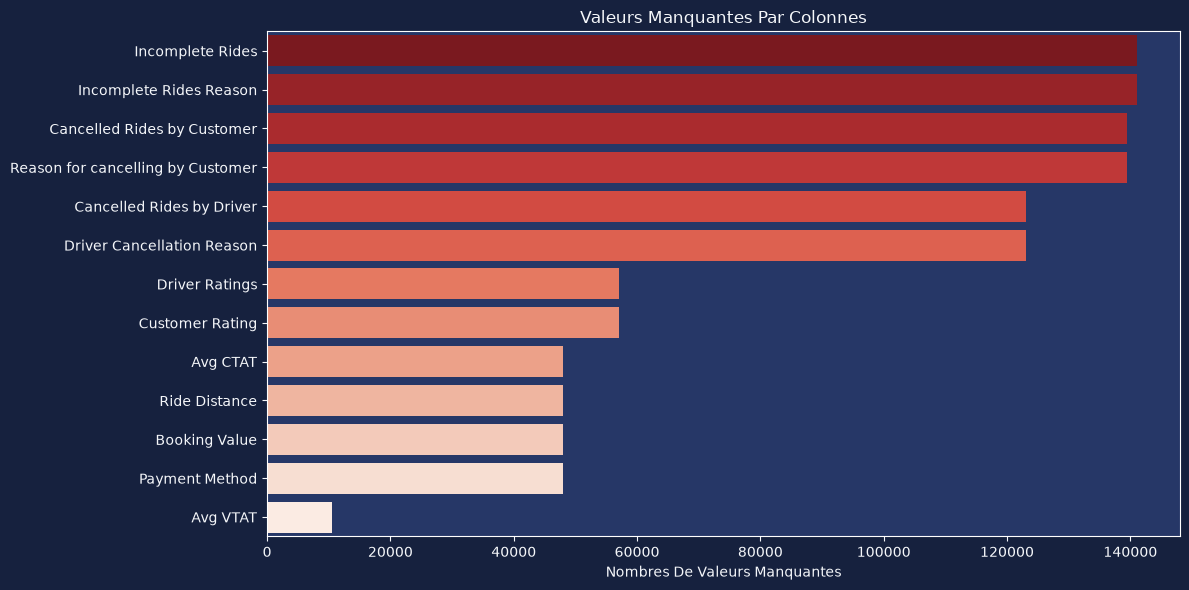

In [3]:
missing = df.isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="Reds_r",
)

plt.title("Valeurs Manquantes Par Colonnes")
plt.xlabel("Nombres De Valeurs Manquantes")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 1. Répartition des statuts des courses
Question : Quel est le taux de réussite des réservations ?

Analyse :

La majorité des courses sont terminées, mais une partie importante est perdue à cause des annulations ou de l'absence de chauffeur.

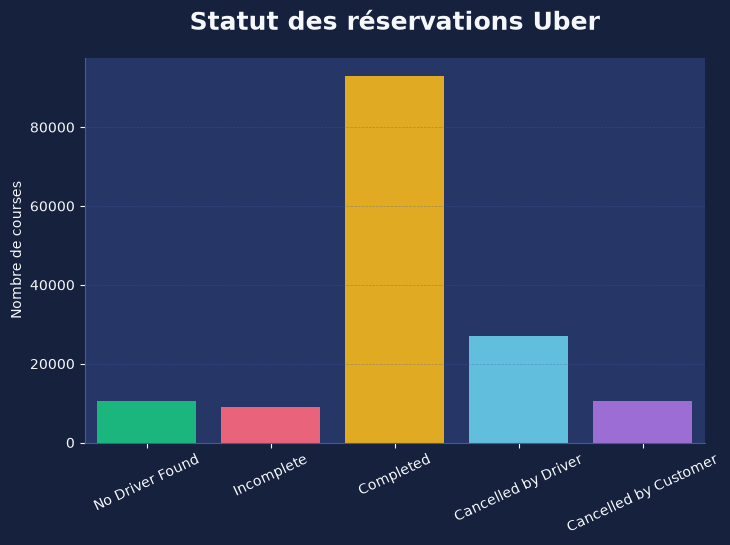

In [4]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Booking Status",
    hue="Booking Status",
    palette=[
        UBER_GREEN,
        RED,
        ORANGE,
        BLUE,
        "#9B5DE5"
    ],
    legend=False
)
uber_style(
    ax,
    "Statut des réservations Uber"
)

plt.xticks(rotation=25)
plt.ylabel("Nombre de courses")
plt.xlabel("")
plt.grid(axis = "x")
plt.show()

### 2. Causes d'annulation client

Analyse :

Les principales causes permettent d'identifier les problèmes d'expérience client.

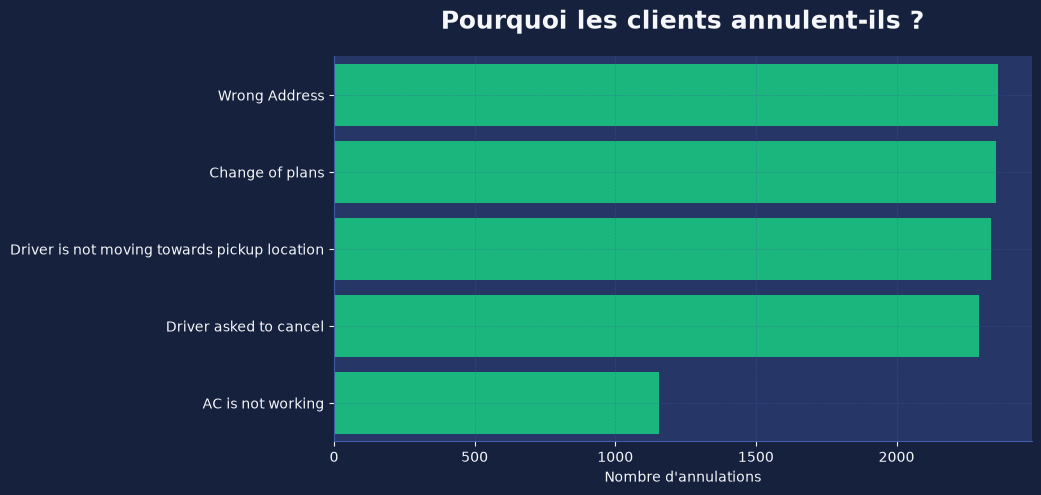

In [5]:
cancel_client = (
    df["Reason for cancelling by Customer"]
    .value_counts()
)


plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=cancel_client.values,
    y=cancel_client.index,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Pourquoi les clients annulent-ils ?"
)

plt.xlabel("Nombre d'annulations")
plt.ylabel("")

plt.show()

### 3. Annulations chauffeurs

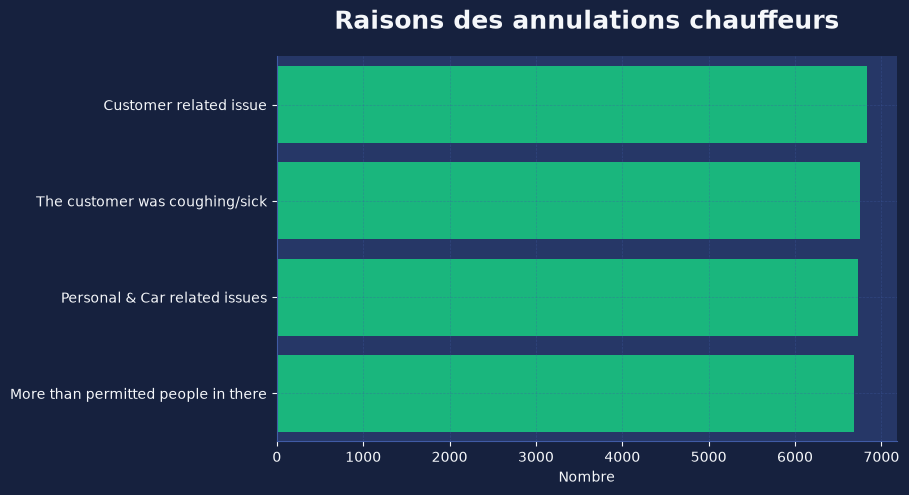

In [6]:
driver_cancel = (
    df["Driver Cancellation Reason"]
    .value_counts()
)


plt.figure(figsize=(8,5))

ax=sns.barplot(
    x=driver_cancel.values,
    y=driver_cancel.index,
    color="#00D084"
)

uber_style(
    ax,
    "Raisons des annulations chauffeurs"
)

plt.xlabel("Nombre")
plt.ylabel("")

plt.show()


### 4. Véhicules les plus utilisés
Analyse :

Permet d'identifier les véhicules les plus demandés.

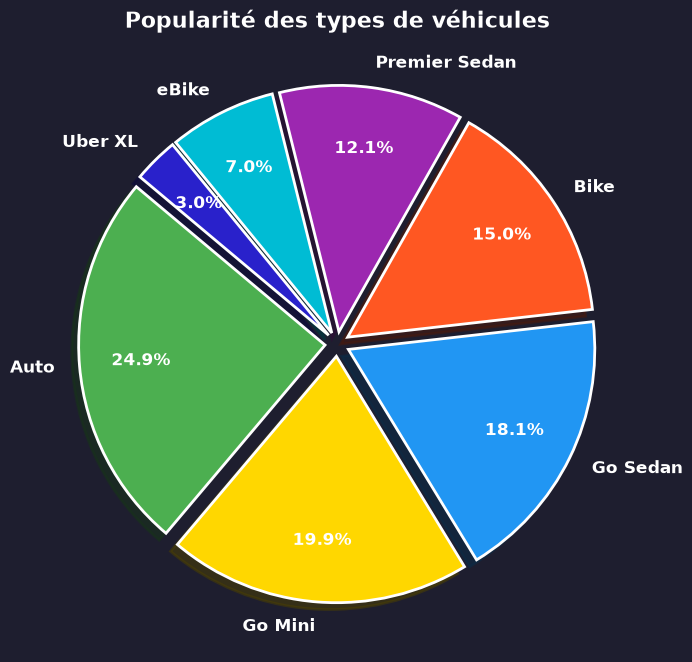

In [7]:
vehicle = df["Vehicle Type"].value_counts()

colors = ["#4CAF50", "#FFD700", "#2196F3", "#FF5722", "#9C27B0", "#00BCD4", "#2921CB"]

plt.figure(figsize=(9, 8), facecolor="#1E1E2F")

plt.pie(
    vehicle,
    labels=vehicle.index,
    colors=colors[:len(vehicle)],
    explode=[0.05] * len(vehicle),   
    startangle=140,
    shadow=True,
    autopct="%1.1f%%",
    pctdistance=0.75,
    textprops={
        "color": "white",
        "fontsize": 12,
        "fontweight": "bold"
    },
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

plt.title(
    "Popularité des types de véhicules",
    color="white",
    fontsize=16,
    fontweight="bold"
)

plt.gca().set_facecolor("#1E1E2F")
plt.show()

### 5. Revenus par type de véhicule

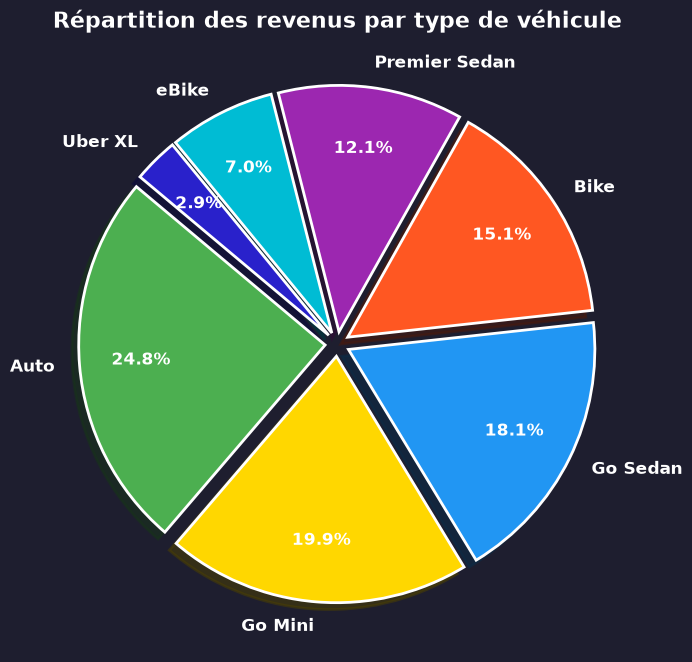

In [8]:
revenue = (
    df.groupby("Vehicle Type")["Booking Value"]
    .sum()
    .sort_values(ascending=False)
)

colors = ["#4CAF50", "#FFD700", "#2196F3", "#FF5722", "#9C27B0", "#00BCD4", "#2921CB"]


plt.figure(figsize=(9, 8), facecolor="#1E1E2F")

plt.pie(
    revenue,
    labels=revenue.index,
    colors=colors[:len(revenue)],
    explode=[0.05] * len(revenue),  
    startangle=140,
    shadow=True,
    autopct="%1.1f%%",
    pctdistance=0.75,
    textprops={
        "color": "white",
        "fontsize": 12,
        "fontweight": "bold"
    },
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

plt.title(
    "Répartition des revenus par type de véhicule",
    color="white",
    fontsize=16,
    fontweight="bold"
)

plt.gca().set_facecolor("#1E1E2F")
plt.show()

### 6. Evolution des réservations par mois

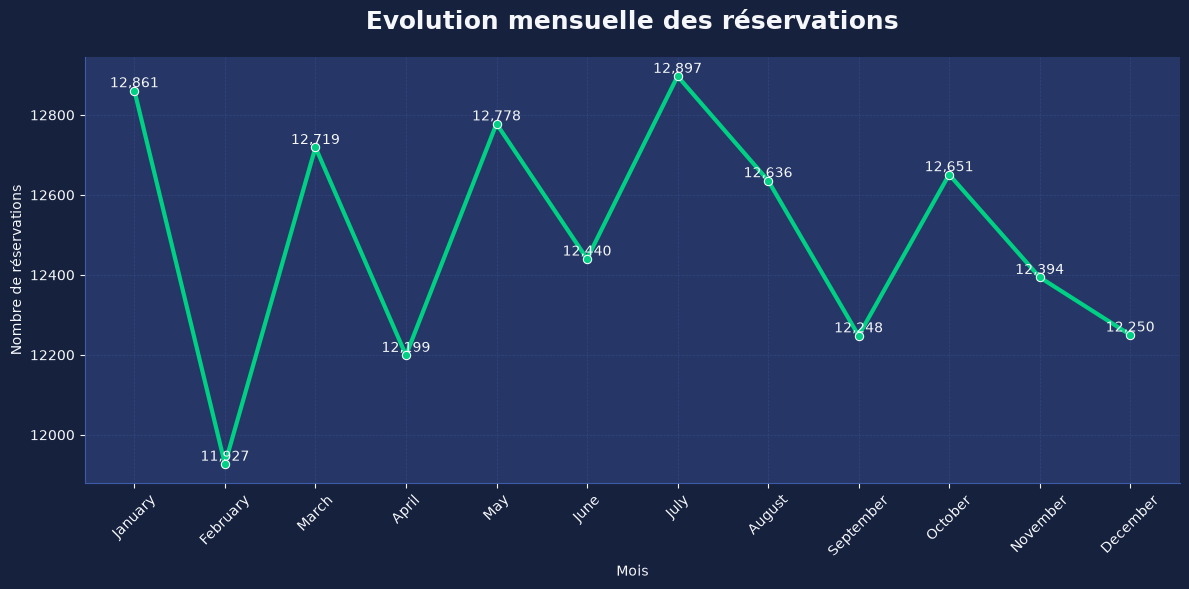

In [9]:
# Convertir la colonne Date
df["Date"] = pd.to_datetime(df["Date"])

# Créer une colonne Mois
df["Month"] = df["Date"].dt.month_name()

# Mettre les mois dans l'ordre chronologique
ordre_mois = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Compter les réservations par mois
monthly = (
    df.groupby("Month")
      .size()
      .reindex(ordre_mois)
)

# Graphique
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    color=UBER_GREEN,
    linewidth=3
)

uber_style(
    ax,
    "Evolution mensuelle des réservations"
)

# Afficher les valeurs
for x, y in zip(monthly.index, monthly.values):
    ax.text(
        x,
        y,
        f"{y:,}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=45)
plt.ylabel("Nombre de réservations")
plt.xlabel("Mois")

plt.tight_layout()
plt.show()

### 7. Heures de pointe

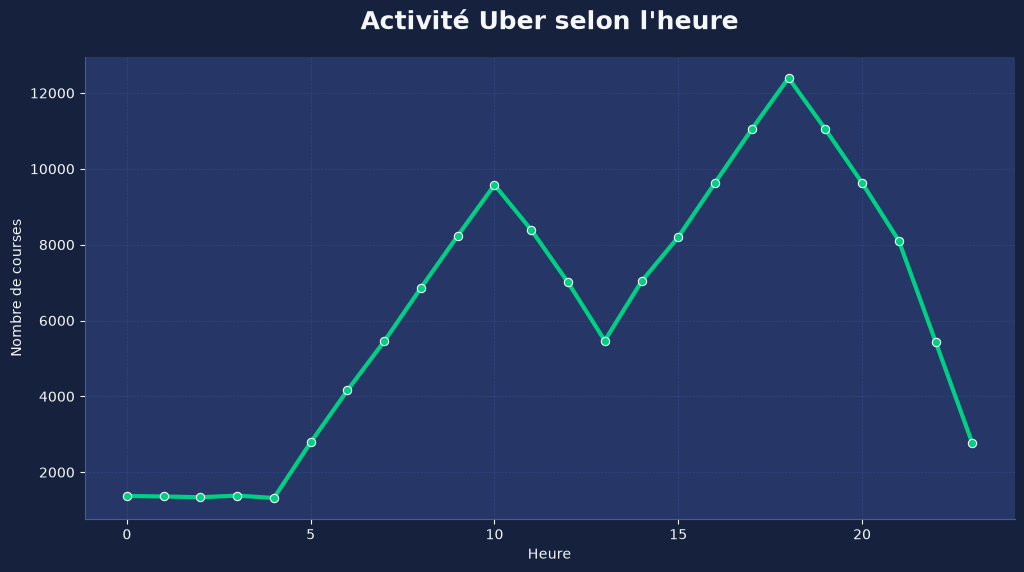

In [10]:
hourly = df["Hour"].value_counts().sort_index()


plt.figure(figsize=(12,6))

ax=sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker="o",
    color=UBER_GREEN,
    linewidth=3
)

uber_style(
    ax,
    "Activité Uber selon l'heure"
)

plt.xlabel("Heure")
plt.ylabel("Nombre de courses")

plt.show()

### 8. Distribution des notes clients

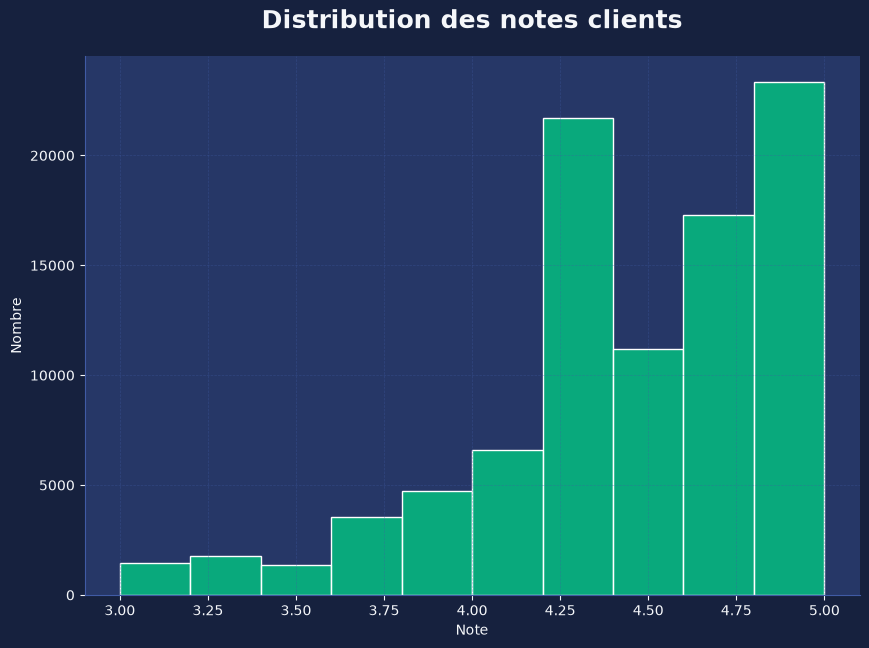

In [11]:
plt.figure(figsize=(10,7))

ax=sns.histplot(
    df["Customer Rating"],
    bins=10,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Distribution des notes clients"
)

plt.xlabel("Note")
plt.ylabel("Nombre")

plt.show()

### 9. Distribution des notes clients

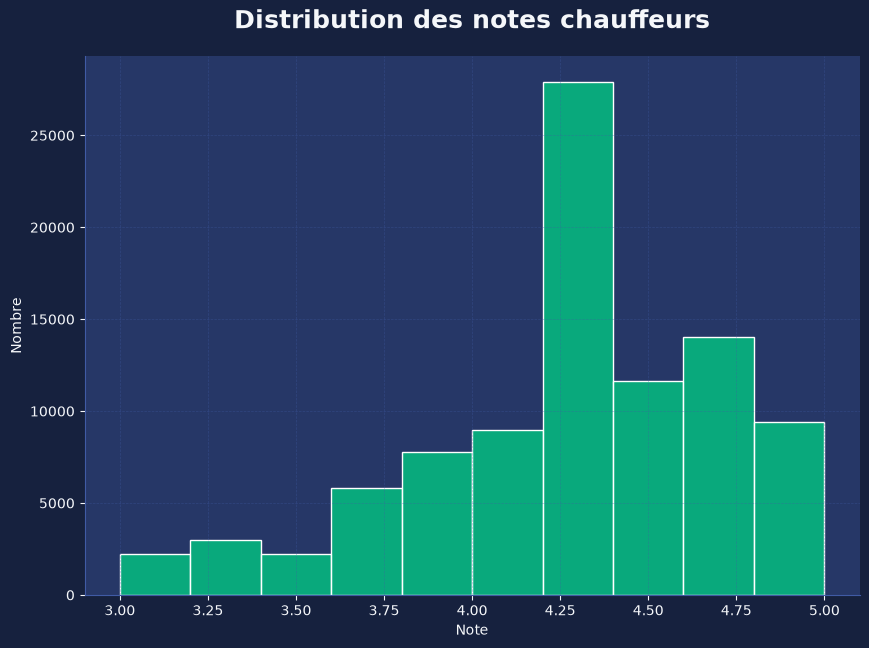

In [12]:
plt.figure(figsize=(10,7))

ax=sns.histplot(
    df["Driver Ratings"],
    bins=10,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Distribution des notes chauffeurs"
)

plt.xlabel("Note")
plt.ylabel("Nombre")

plt.show()

### 10. Carte thermique des réservations (Heures et Jours de la semaine)

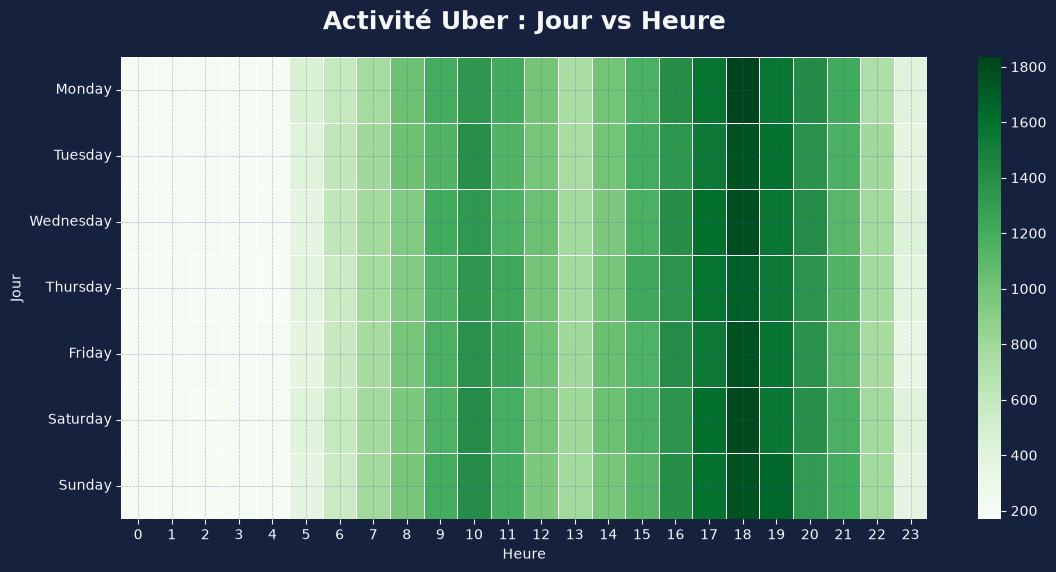

In [13]:
# Conversion Date
df["Date"] = pd.to_datetime(df["Date"])

# Extraire le jour de la semaine
df["Day"] = df["Date"].dt.day_name()

# Extraire l'heure depuis la colonne Time
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour


# Ordre des jours
ordre_jours = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


# Nombre de réservations par jour et par heure
pivot = pd.crosstab(
    df["Day"],
    df["Hour"]
).reindex(ordre_jours)


# Heatmap
plt.figure(figsize=(13,6))

ax = sns.heatmap(
    pivot,
    cmap="Greens",
    annot=False,
    fmt="d",
    linewidths=0.5
)

uber_style(
    ax,
    "Activité Uber : Jour vs Heure"
)

plt.xlabel("Heure")
plt.ylabel("Jour")

plt.show()

### Relation entre Booking Value et Driver Rtatings

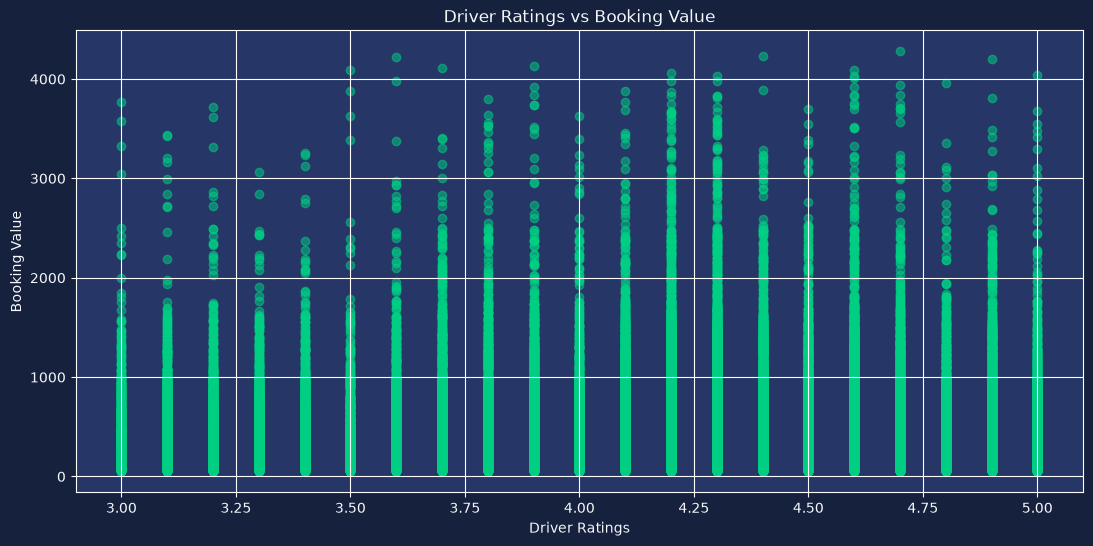

In [14]:
plt.figure(figsize=(13,6))


plt.scatter(
    df[df.columns[df.columns.str.lower().str.replace(' ', '_') == 'driver_ratings'][0]],
    df[df.columns[df.columns.str.lower().str.replace(' ', '_') == 'booking_value'][0]],
    alpha=0.5, color = UBER_GREEN   
)

plt.title('Driver Ratings vs Booking Value')
plt.xlabel('Driver Ratings')
plt.ylabel('Booking Value')
plt.grid(True)
plt.show()

### Top 10 des lieux de prises en charges (Pickup)

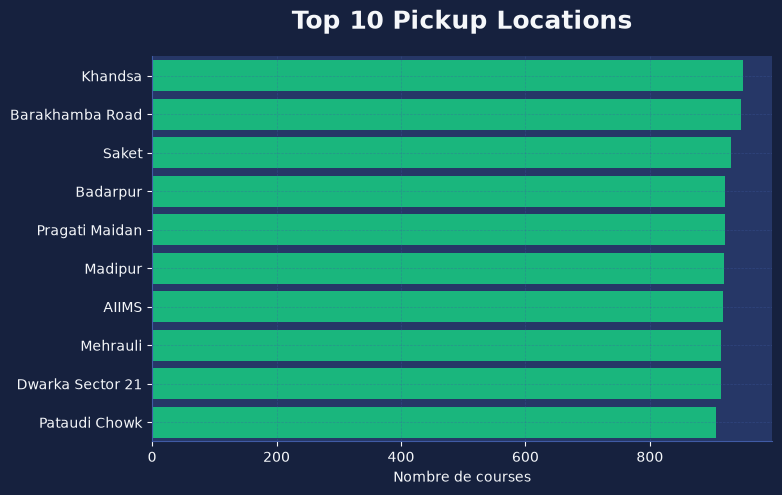

In [15]:

top10 = df["Pickup Location"].value_counts().head(10)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=top10.values,
    y=top10.index,
    color="#00D084"
)

uber_style(
    ax,
    "Top 10 Pickup Locations"
)

plt.xlabel("Nombre de courses")
plt.ylabel("")

plt.show()


### Relation entre Avg VTAT et Incompletes Rides\Cancelled by Customer

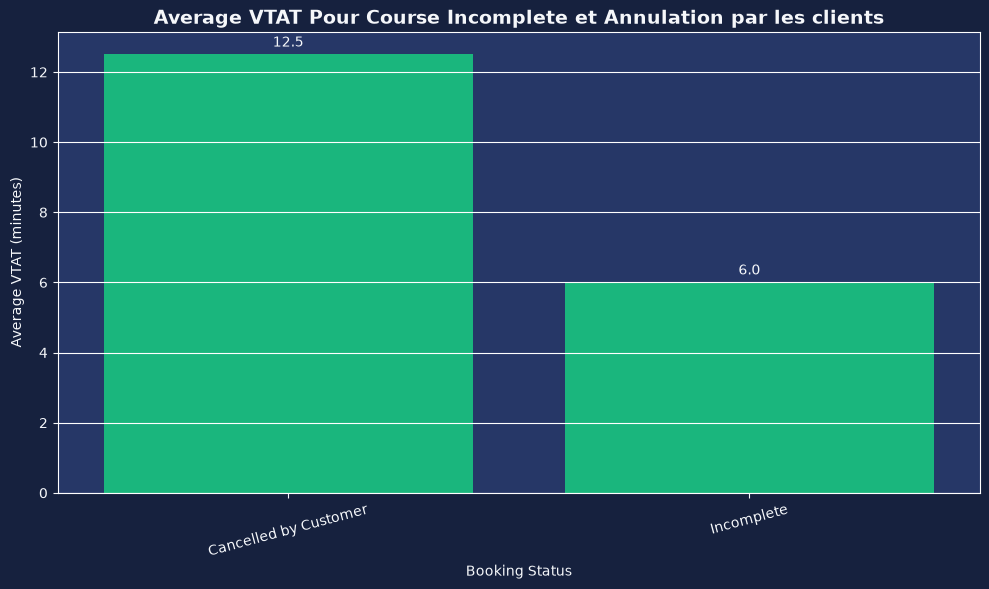

In [16]:
vtat_status = (
    df[df["Booking Status"].isin(
        ["Incomplete", "Cancelled by Customer"]
    )]
    .groupby("Booking Status")["Avg VTAT"]
    .mean()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=vtat_status.index,
    y=vtat_status.values,
    color="#00D084"
)

ax.set_title(
    "Average VTAT Pour Course Incomplete et Annulation par les clients",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Booking Status")
ax.set_ylabel("Average VTAT (minutes)")


# Ajouter les valeurs
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.grid(axis="y")
plt.show()

# Analyse des VTAT élevés et des annulations à New Delhi (Inde)

## Contexte général

Les statistiques de **VTAT (Valeur Temps d'Attente)** et d'annulation à New Delhi sont particulièrement élevées et atypiques par rapport aux standards occidentaux.

Un **VTAT moyen de 12,5 minutes avant annulation** s'explique par plusieurs facteurs structurels, culturels et technologiques propres au marché indien des VTC, notamment sur des plateformes comme **Uber** et **Ola**.

Les principaux facteurs sont :

1. Le phénomène du **"Caché-Négocié"** (destination à l'aveugle)
2. La préférence forte pour le **paiement en espèces**
3. La congestion urbaine extrême de Delhi NCR
4. La tolérance culturelle des clients face aux frictions du transport

---

# 1. Le phénomène du "Caché-Négocié"  
## Destination à l'aveugle

### Manque de transparence initial

Historiquement, certaines applications VTC en Inde ne montraient pas toujours au chauffeur :

- La destination finale du client
- Le mode de paiement choisi (espèces ou paiement numérique)

Le chauffeur acceptait donc la course sans connaître tous les détails.

---

## Le coup de téléphone systématique

Une fois la course acceptée, le chauffeur appelle souvent le client pour demander :

> "Drop kahan hai ?"  
> *(Où allez-vous ?)*

et :

> "Cash ou en ligne ?"

L'objectif est de vérifier :

- Si la destination lui convient
- Si le paiement sera effectué en espèces
- Si la course est suffisamment rentable

---

## La guerre d'usure

Si la destination ou le mode de paiement ne convient pas :

- Le chauffeur refuse parfois de démarrer
- Il évite d'annuler lui-même pour ne pas dégrader son taux d'annulation
- Il attend que le client perde patience et annule

Cette stratégie crée une **guerre psychologique** qui augmente artificiellement le temps d'attente.

Résultat :

> Le VTAT moyen peut dépasser 12 minutes avant l'annulation.

---

# 2. La préférence absolue pour le Cash

## Besoin de liquidités immédiates

Une partie importante des chauffeurs privilégie les paiements en espèces.

Raisons principales :

- Paiement immédiat
- Besoin quotidien de liquidités
- Paiement du carburant (notamment GNC - gaz naturel comprimé)
- Paiement des frais de location ou d'exploitation du véhicule

---

## Évitement des commissions

Lorsqu'un client choisit un paiement numérique :

- Carte bancaire
- Portefeuille électronique
- Paiement intégré à l'application

Certains chauffeurs peuvent demander :

1. D'annuler la course dans l'application
2. De réaliser le trajet directement en liquide
3. D'éviter les commissions de la plateforme

Ce processus de négociation rallonge fortement :

- Le temps avant départ
- Le temps avant annulation officielle

---

# 3. La congestion urbaine extrême et la géographie de Delhi NCR

## Embouteillages imprévisibles

La région de Delhi NCR comprend notamment :

- New Delhi
- Noida
- Gurugram

La circulation y est extrêmement dense.

Problème fréquent :

- L'application indique un chauffeur à 3 minutes
- Le chauffeur est bloqué dans un embouteillage
- Le temps réel devient beaucoup plus long

---

## Le problème du trajet retour

Certains chauffeurs refusent certaines destinations lorsqu'elles impliquent :

- Un retour à vide
- Une faible probabilité de trouver une nouvelle course
- Des coûts supplémentaires liés aux frontières entre États
- Des taxes ou contraintes administratives

Certaines zones périphériques deviennent donc moins attractives.

---

# 4. La tolérance culturelle des clients

## Une habitude de la négociation

Les utilisateurs de Delhi sont habitués aux frictions liées aux transports :

- Auto-rickshaws
- Taxis locaux
- Négociations de prix

Ils acceptent donc plus facilement :

- Les appels téléphoniques
- Les discussions avec le chauffeur
- Les temps d'attente prolongés

---

## Impact sur le VTAT

Cette tolérance entraîne un comportement particulier :

1. Le client attend plusieurs minutes
2. Il espère que le chauffeur finira par accepter
3. Il annule seulement après une longue attente

Conséquence :

> Le temps moyen avant annulation augmente fortement.

---

# Synthèse des causes principales

| Facteur | Effet sur le VTAT |
|---|---|
| Destination cachée avant acceptation | Appels et négociations après acceptation |
| Préférence pour le cash | Refus des paiements numériques |
| Stratégie d'attente du chauffeur | Le client annule à la place du chauffeur |
| Embouteillages de Delhi NCR | Temps d'arrivée imprévisible |
| Refus de certaines zones | Courses abandonnées |
| Tolérance des clients | Annulations plus tardives |

---

# Réponse réglementaire

Pour limiter ce phénomène, les autorités de New Delhi ont envisagé des régulations plus strictes comprenant :

- Des sanctions contre les annulations injustifiées
- Des amendes pour les chauffeurs refusant des courses sans raison valable
- Une meilleure transparence entre plateformes, chauffeurs et clients

---

# Conclusion

Le VTAT élevé de New Delhi n'est pas uniquement un problème de circulation.

Il résulte d'une combinaison de :

- Manque de transparence historique des plateformes
- Arbitrages économiques des chauffeurs
- Préférence pour les paiements en espèces
- Contraintes géographiques
- Habitudes culturelles de négociation

Le résultat est un marché où l'annulation devient souvent une **négociation indirecte entre chauffeur et passager**, ce qui augmente artificiellement le temps d'attente moyen.

Le VTAT moyen (exprimé en minutes) est plus de deux fois plus élevé pour les courses annulées par le client que pour les courses incomplètes.

Voici l'analyse directe des données de votre graphique :Les Données ClésCancelled by Customer (Annulée par le client) : Le VTAT moyen est de 12,5 minutes.Incomplete (Incomplete) : Le VTAT moyen est de 6,0 minutes.Interprétation des 

RésultatsSeuil critique des 12 minutes : Un VTAT de 12,5 minutes avant une annulation client montre que les utilisateurs ont tendance à patienter environ un quart d'heure avant de perdre patience et d'annuler leur réservation.

Rapidité du statut incomplet : Le statut "Incomplete" survient beaucoup plus tôt (6,0 minutes). Cela correspond généralement à des erreurs techniques immédiates, des rejets algorithmiques rapides ou des abandons dès la prise en charge.

In [17]:
print(df.columns.tolist())

['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'Month', 'Day', 'Hour']


### Distance moyenne parcourue par type de véhicule

In [32]:

df.columns = df.columns.str.strip()

# Vérification

# Garder uniquement les trajets terminés
df = df[df["Booking Status"] == "Completed"]

# Taille minimale par catégorie
n = df["Vehicle Type"].value_counts().min()

# Échantillonnage équilibré
df_equilibre = (
    df.groupby("Vehicle Type", group_keys=False)
      .sample(n=n, random_state=42)
)

# Calcul de la distance moyenne
distance_moyenne = (
    df_equilibre.groupby("Vehicle Type")["Ride Distance"]
    .agg(
        Nombre_de_trajets="count",
        Distance_moyenne="mean",
        Ecart_type="std"
    )
    .round(2)
)


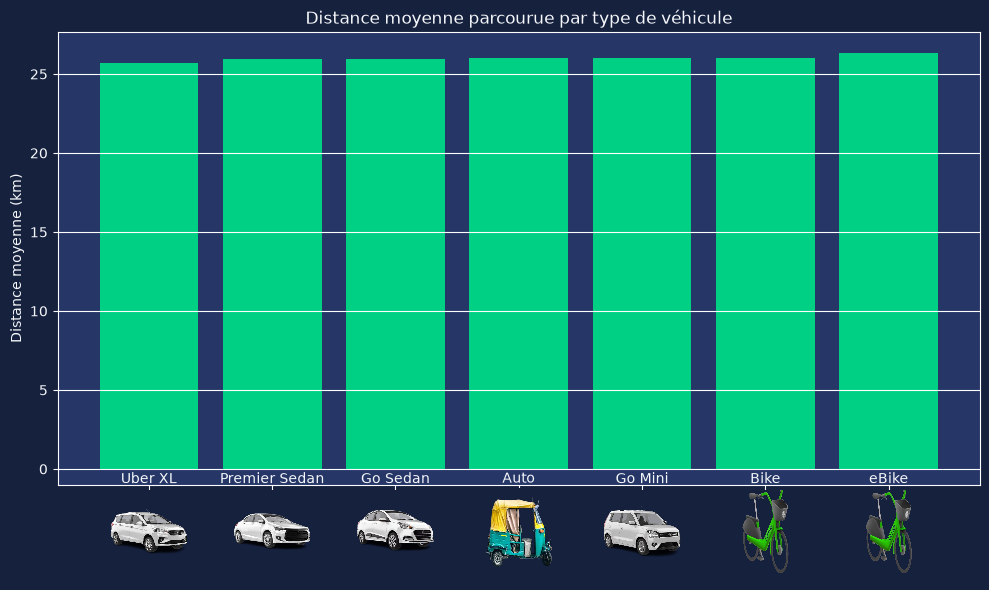

In [33]:
# Distance moyenne par type de véhicule
distance_moyenne = (
    df.groupby("Vehicle Type")["Ride Distance"]
      .mean()
      .sort_values()
)
# Images des véhicules
images = {
       "Auto": "images/Auto.jpg", 
       "eBike": "images/eBike.jpg", 
       "Go Mini": "images/GoMini.jpg", 
       "Go Sedan": "images/GoSedan.jpg", 
       "Uber XL": "images/UberXL.jpg", 
       "Premier Sedan": "images/Premier Sedan.jpg", 
       "Bike": "images/eBike.jpg" 
}

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(range(len(distance_moyenne)),
              distance_moyenne.values,
              color=UBER_GREEN)

ax.set_title("Distance moyenne parcourue par type de véhicule")
ax.set_ylabel("Distance moyenne (km)")

# Supprimer les labels texte
ax.set_xticks(range(len(distance_moyenne)))
ax.set_xticklabels([])

# Ajouter les images
# Ajouter les images et les noms
for i, vehicule in enumerate(distance_moyenne.index):
    img = mpimg.imread(images[vehicule])
    imagebox = OffsetImage(img, zoom=0.12)

    ab = AnnotationBbox(
        imagebox,
        (i, 0),
        xybox=(0, -45),
        xycoords='data',
        boxcoords="offset points",
        frameon=False
    )
    ax.add_artist(ab)

    # Nom du véhicule sous l'image
    ax.text(
        i, -0.2,                 # Ajuster cette valeur selon la taille des images
        vehicule,
        ha='center',
        va='top',
        fontsize=10
    )

# Laisser de la place sous le graphique
ax.set_ylim(bottom=-1)

plt.tight_layout()
plt.grid(axis="y")
plt.show()

### Classement des Méthodes de paiement

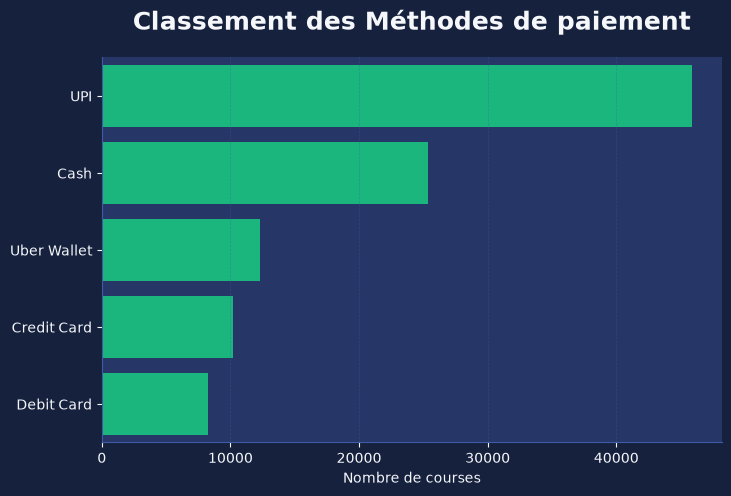

In [ ]:

TopPayment = df["Payment Method"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=TopPayment.values,
    y=TopPayment.index,
    color="#00D084"
)

uber_style(
    ax,
    "Classement des Méthodes de paiement"
)

plt.xlabel("Nombre de courses")
plt.ylabel("")
plt.grid(axis="y")
plt.show()

In [34]:
duplicate_count = rides = pd.read_csv("ncr_ride_bookings_clean.csv")["Pickup Location"].duplicated().sum()

print(f"Number of duplicate Pickup Locations: {duplicate_count}")

Number of duplicate Pickup Locations: 149824


In [ ]:
df = pd.read_csv("locations_gps.csv")


# ==============================
# Classification des zones
# ==============================

rich_zones = [
    "Palam Vihar",
    "Central Secretariat",
    "AIIMS",
    "Udyog Bhawan",
    "Vidhan Sabha",
    "Patel Chowk",
    "Pitampura",
    "Punjabi Bagh",
    "Noida Sector 18",
    "Cyber Hub",
    "Qutub Minar",
    "DLF City Court",
    "Civil Lines Gurgaon",
    "Rajiv Chowk",
    "MG Road",
    "Ardee City",
    "Lajpat Nagar",
    "Sushant Lok",
    "IIT Delhi",
    "Khan Market",
    "DLF Phase 3",
]


poor_zones = [
    "Khandsa",
    "Madipur",
    "Jama Masjid",
    "Okhla",
    "Sadar Bazar Gurgaon",
    "Shastri Park",
    "Mundka",
    "Seelampur",
    "Dilshad Garden",
    "Aya Nagar",
    "Tughlakabad",
    "Shahdara",
    "Welcome",
    "Jahangirpuri",
    "Govindpuri",
    "Badarpur",
    "Samaypur Badli",
    "Paharganj",
    "Gurgaon Railway Station",
    "Basai Dhankot",
    "Bhiwadi"
]


# ==============================
# Fonction de classification
# ==============================

def classify_income(place):

    if place in rich_zones:
        return "Rich"

    elif place in poor_zones:
        return "Poor"

    else:
        return "Middle"


# Ajouter la colonne
df["Income_Level"] = df["Place"].apply(classify_income)


# Sauvegarder
df.to_csv(
    "locations_gps_income.csv",
    index=False,
    encoding="utf-8"
)


print("Fichier créé : locations_gps_income.csv")
print(df["Income_Level"].value_counts())


Fichier créé : locations_gps_income.csv
Income_Level
Middle    134
Rich       21
Poor       21
Name: count, dtype: int64


### Analyse du Taux d'annulation par rapport aux zones les plus pauvres 

In [ ]:
import pandas as pd

# Charger les fichiers
rides = pd.read_csv("ncr_ride_bookings_clean.csv")
locations = pd.read_csv("locations_gps_income.csv")

# Supprimer les doublons sur Pickup Location
rides = rides.drop_duplicates(subset="Pickup Location")

# Supprimer les doublons sur Place
locations = locations.drop_duplicates(subset="Place")

# Fusionner
rides = rides.merge(
    locations[["Place", "Income_Level"]],
    left_on="Pickup Location",
    right_on="Place",
    how="left"
)

# Supprimer la colonne Place
rides.drop(columns=["Place"], inplace=True)

# Sauvegarder
rides.to_csv(
    "ncr_ride_bookings_with_income.csv",
    index=False,
    encoding="utf-8"
)

print("Dataset créé :", rides.shape)


Dataset créé : (176, 22)


Cancelled
False    138
True      38
Name: count, dtype: int64


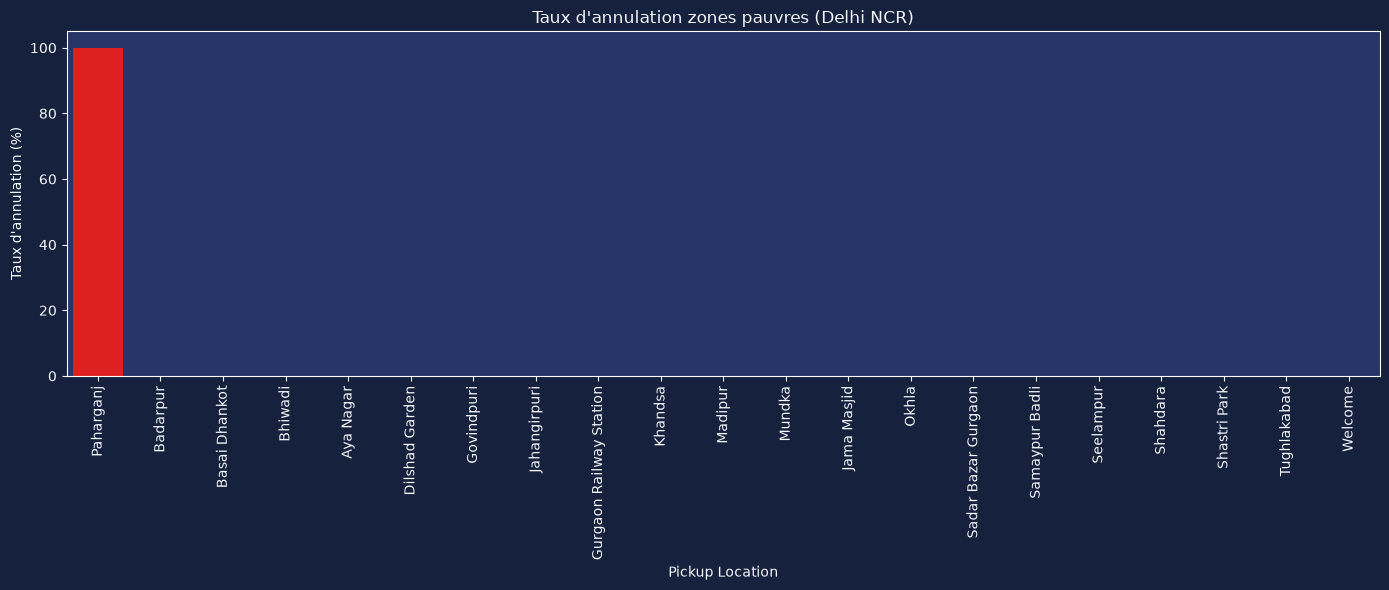

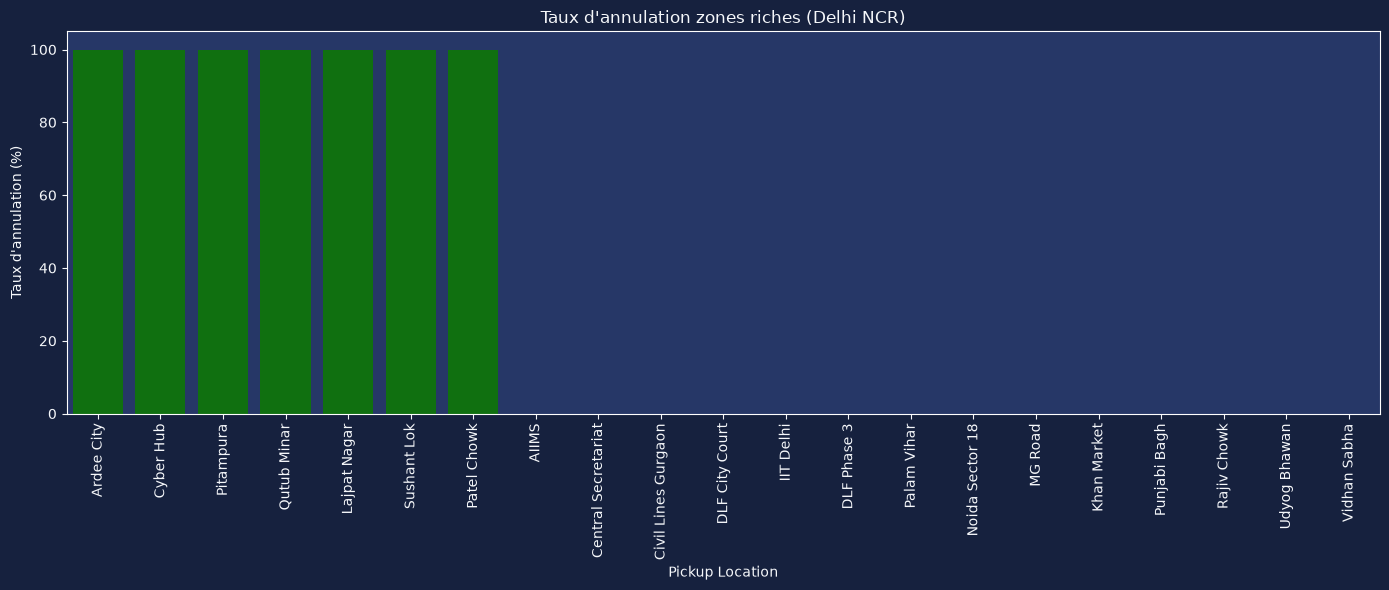

In [ ]:
df = pd.read_csv("ncr_ride_bookings_with_income.csv")


# ==============================
# Créer la variable Annulation
# uniquement client + chauffeur
# ==============================

df["Cancelled"] = (
    df["Cancelled Rides by Customer"].notna()
    |
    df["Cancelled Rides by Driver"].notna()
)


# Vérification
print(df["Cancelled"].value_counts())


# ==============================
# Taux d'annulation par zone
# ==============================

cancel_rate = (
    df.groupby(["Income_Level", "Pickup Location"])
    ["Cancelled"]
    .mean()
    .reset_index()
)

cancel_rate["Cancellation Rate (%)"] = (
    cancel_rate["Cancelled"] * 100
)


# ==============================
# Graphique zones pauvres
# ==============================

poor = (
    cancel_rate[cancel_rate["Income_Level"] == "Poor"]
    .sort_values(
        "Cancellation Rate (%)",
        ascending=False
    )
)


plt.figure(figsize=(14,6))

sns.barplot(
    data=poor,
    x="Pickup Location",
    y="Cancellation Rate (%)",
    color="red"
)

plt.xticks(rotation=90)

plt.title(
    "Taux d'annulation zones pauvres (Delhi NCR)"
)

plt.xlabel("Pickup Location")
plt.ylabel("Taux d'annulation (%)")

plt.tight_layout()
plt.show()



# ==============================
# Graphique zones riches
# ==============================

rich = (
    cancel_rate[cancel_rate["Income_Level"] == "Rich"]
    .sort_values(
        "Cancellation Rate (%)",
        ascending=False
    )
)


plt.figure(figsize=(14,6))

sns.barplot(
    data=rich,
    x="Pickup Location",
    y="Cancellation Rate (%)",
    color="green"
)

plt.xticks(rotation=90)

plt.title(
    "Taux d'annulation zones riches (Delhi NCR)"
)

plt.xlabel("Pickup Location")
plt.ylabel("Taux d'annulation (%)")

plt.tight_layout()
plt.show()

C:\Users\axelg\AppData\Local\Temp\ipykernel_5868\1718579708.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


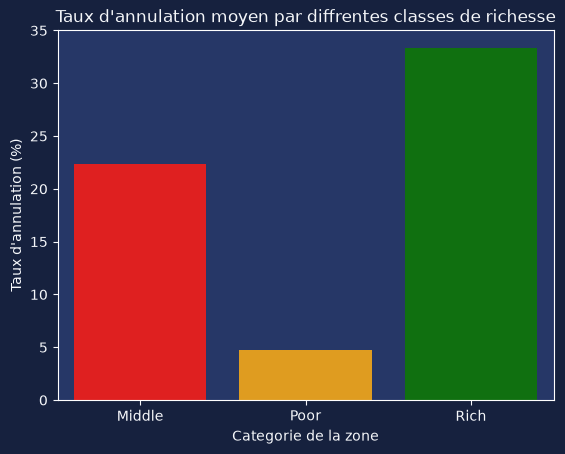

In [ ]:
avg_income = (
    df.groupby("Income_Level")["Cancelled"]
    .mean()
    .reset_index()
)

avg_income["Cancellation Rate (%)"] = (
    avg_income["Cancelled"] * 100
)

sns.barplot(
    data=avg_income,
    x="Income_Level",
    y="Cancellation Rate (%)",
    palette=["red","orange","green"]
)

plt.title("Taux d'annulation moyen par diffrentes classes de richesse")
plt.ylabel("Taux d'annulation (%)")
plt.xlabel("Categorie de la zone")
plt.show()

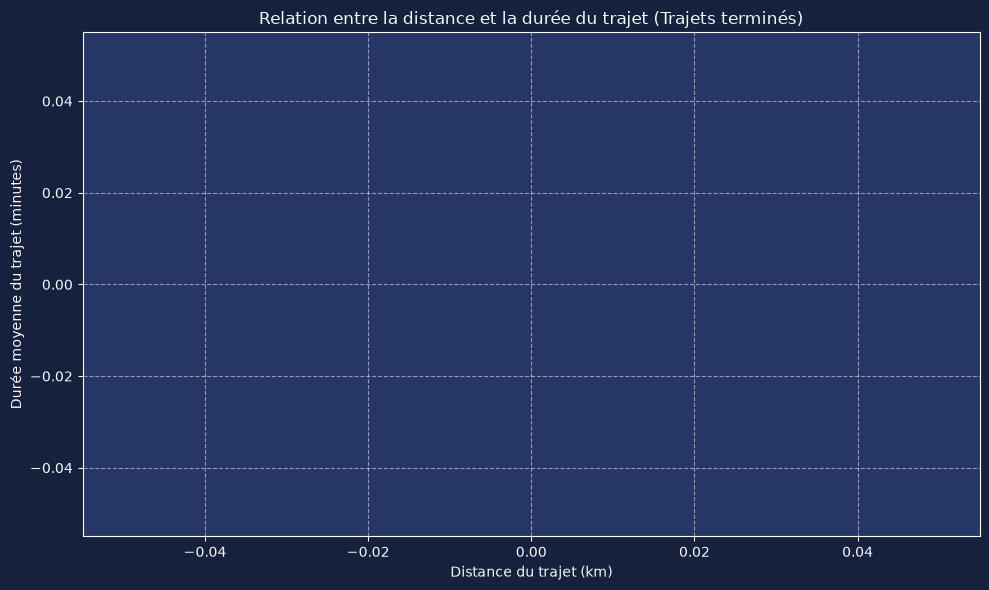

In [ ]:
# Filtrer uniquement les trajets terminés pour éviter les anomalies
completed_rides = df[df["Booking Status"] == "Cancelled by Driver"]

# Création du nuage de points
plt.figure(figsize=(10, 6))
plt.scatter(
    completed_rides["Ride Distance"],
    completed_rides["Avg CTAT"],
    alpha=0.5,
    color="#ff7f0e",
    edgecolors="none",
)

plt.title("Relation entre la distance et la durée du trajet (Trajets terminés)")
plt.xlabel("Distance du trajet (km)")
plt.ylabel("Durée moyenne du trajet (minutes)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
